In [1]:
# Cell 1: Build H2 fermionic Hamiltonian and Hermitian fermionic terms

import pandas as pd

from openfermion.chem import MolecularData
from openfermion.ops import FermionOperator
from openfermion.transforms import get_fermion_operator, normal_ordered
from openfermion.utils import hermitian_conjugated
from openfermionpyscf import run_pyscf

pd.set_option("display.max_colwidth", None)


def format_fermion_term(term):
    if term == ():
        return "I"

    pieces = []
    for orbital, action in term:
        if action == 1:
            pieces.append(f"a_{orbital}^dagger")
        else:
            pieces.append(f"a_{orbital}")
    return " ".join(pieces)


def sort_fermion_key(term):
    return (len(term), term)


def coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_fermion_key(item[0])):
        pieces.append(f"{coeff_to_str(coeff, digits)} {format_fermion_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def dagger_term_key(term):
    """
    Return the OpenFermion key for O^dagger, where O is one monomial.
    """
    O = FermionOperator(term, 1.0)
    O_dag = normal_ordered(hermitian_conjugated(O))
    O_dag.compress(abs_tol=1e-12)

    if len(O_dag.terms) != 1:
        raise ValueError(f"Expected one dagger term, got: {O_dag}")

    return next(iter(O_dag.terms.keys()))


def make_hermitian_fermionic_terms(fermion_hamiltonian, tol=1e-12):
    """
    Group raw monomials into Hermitian fermionic Hamiltonian terms.

    If O is self-adjoint, keep c O.
    If O is not self-adjoint, group c O + c* O^dagger.
    """
    used = set()
    hermitian_terms = []

    for term, coeff in fermion_hamiltonian.terms.items():
        if term in used:
            continue

        dag = dagger_term_key(term)

        if dag == term:
            T = FermionOperator(term, coeff)
            used.add(term)
        else:
            dag_coeff = fermion_hamiltonian.terms.get(dag, 0.0)

            T = FermionOperator(term, coeff)
            T += FermionOperator(dag, dag_coeff)

            used.add(term)
            used.add(dag)

        T = normal_ordered(T)
        T.compress(abs_tol=tol)
        hermitian_terms.append(T)

    return hermitian_terms


def build_h8_fermionic_hamiltonian(
    bond_length=0.7414,
    basis="sto-3g",
    multiplicity=1,
    charge=0,
):
    geometry = [
        ("H", (0.0, 0.0, 0.0 * bond_length)),
        ("H", (0.0, 0.0, 1.0 * bond_length)),
        ("H", (0.0, 0.0, 2.0 * bond_length)),
        ("H", (0.0, 0.0, 3.0 * bond_length)),
        ("H", (0.0, 0.0, 4.0 * bond_length)),
        ("H", (0.0, 0.0, 5.0 * bond_length)),
        ("H", (0.0, 0.0, 6.0 * bond_length)),
        ("H", (0.0, 0.0, 7.0 * bond_length)),
    ]

    molecule = MolecularData(
        geometry=geometry,
        basis=basis,
        multiplicity=multiplicity,
        charge=charge,
        description=f"H8_{bond_length}",
    )

    molecule = run_pyscf(
        molecule,
        run_scf=True,
        run_fci=False,
    )

    molecular_hamiltonian = molecule.get_molecular_hamiltonian()
    fermion_hamiltonian = get_fermion_operator(molecular_hamiltonian)

    fermion_hamiltonian = normal_ordered(fermion_hamiltonian)
    fermion_hamiltonian.compress(abs_tol=1e-12)

    return molecule, fermion_hamiltonian


molecule, Hf = build_h8_fermionic_hamiltonian(
    bond_length=0.7414,
    basis="sto-3g",
)

hermitian_terms = make_hermitian_fermionic_terms(Hf)

print("Molecule: H8")
print("Basis: STO-3G")
print("Number of electrons:", molecule.n_electrons)
print("Number of spatial orbitals:", molecule.n_orbitals)
print("Number of spin orbitals / fermionic modes:", molecule.n_qubits)
print("Number of raw OpenFermion monomial terms:", len(Hf.terms))
print("Number of Hermitian fermionic terms:", len(hermitian_terms))

print("\n=== Full fermionic Hamiltonian H_f ===")
print(Hf)


# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

raw_rows = []

for idx, (term, coeff) in enumerate(
    sorted(Hf.terms.items(), key=lambda item: sort_fermion_key(item[0]))
):
    raw_rows.append(
        {
            "raw_index": idx,
            "coefficient": coeff_to_str(coeff),
            "monomial": format_fermion_term(term),
            "OpenFermion_key": term,
        }
    )

raw_df = pd.DataFrame(raw_rows)

print("\n=== Raw fermionic monomials c_alpha O_alpha ===")
display(raw_df)


hermitian_rows = []

for i, T in enumerate(hermitian_terms):
    hermitian_rows.append(
        {
            "vertex": f"T_{i}",
            "number_of_monomials": len(T.terms),
            "fermionic_term": operator_to_string(T),
        }
    )

hermitian_df = pd.DataFrame(hermitian_rows)

print("\n=== Hermitian fermionic terms T_i ===")
display(hermitian_df)

Molecule: H8
Basis: STO-3G
Number of electrons: 8
Number of spatial orbitals: 8
Number of spin orbitals / fermionic modes: 16
Number of raw OpenFermion monomial terms: 2913
Number of Hermitian fermionic terms: 1525

=== Full fermionic Hamiltonian H_f ===
9.809019170392693 [] +
-3.2111925682811995 [0^ 0] +
0.17369672286871027 [0^ 4] +
0.048797642421736176 [0^ 8] +
-0.03288404740983226 [0^ 12] +
-0.4508154878328407 [1^ 0^ 1 0] +
-0.1358937323500319 [1^ 0^ 3 2] +
-0.08202904851719298 [1^ 0^ 4 1] +
0.08202904851719298 [1^ 0^ 5 0] +
-0.08801780676229672 [1^ 0^ 5 4] +
0.055496597259912024 [1^ 0^ 6 3] +
-0.055496597259912024 [1^ 0^ 7 2] +
-0.07389611104940479 [1^ 0^ 7 6] +
0.0066256016032466315 [1^ 0^ 8 1] +
-0.041024765552688774 [1^ 0^ 8 5] +
-0.0066256016032466315 [1^ 0^ 9 0] +
0.041024765552688774 [1^ 0^ 9 4] +
-0.06116428794203599 [1^ 0^ 9 8] +
-0.0006528440172696419 [1^ 0^ 10 3] +
-0.029779543204245713 [1^ 0^ 10 7] +
0.0006528440172696419 [1^ 0^ 11 2] +
0.029779543204245713 [1^ 0^ 11 6] 

,raw_index,coefficient,monomial,OpenFermion_key
0,0,+9.80901917,I,()
1,1,-3.21119257,a_0^dagger a_0,"((0, 1), (0, 0))"
2,2,+0.17369672,a_0^dagger a_4,"((0, 1), (4, 0))"
3,3,+0.04879764,a_0^dagger a_8,"((0, 1), (8, 0))"
4,4,-0.03288405,a_0^dagger a_12,"((0, 1), (12, 0))"
...,...,...,...,...
2908,2908,+0.10810271,a_15^dagger a_14^dagger a_14 a_11,"((15, 1), (14, 1), (14, 0), (11, 0))"
2909,2909,+0.00333118,a_15^dagger a_14^dagger a_15 a_2,"((15, 1), (14, 1), (15, 0), (2, 0))"
2910,2910,+0.00296004,a_15^dagger a_14^dagger a_15 a_6,"((15, 1), (14, 1), (15, 0), (6, 0))"
2911,2911,-0.10810271,a_15^dagger a_14^dagger a_15 a_10,"((15, 1), (14, 1), (15, 0), (10, 0))"



=== Hermitian fermionic terms T_i ===


,vertex,number_of_monomials,fermionic_term
0,T_0,1,+9.80901917 I
1,T_1,1,-3.21119257 a_0^dagger a_0
2,T_2,2,+0.17369672 a_0^dagger a_4 + +0.17369672 a_4^dagger a_0
3,T_3,2,+0.04879764 a_0^dagger a_8 + +0.04879764 a_8^dagger a_0
4,T_4,2,-0.03288405 a_0^dagger a_12 + -0.03288405 a_12^dagger a_0
...,...,...,...
1520,T_1520,2,+0.17963264 a_14^dagger a_13^dagger a_15 a_12 + +0.17963264 a_15^dagger a_12^dagger a_14 a_13
1521,T_1521,1,-0.46345553 a_15^dagger a_12^dagger a_15 a_12
1522,T_1522,1,-0.46345553 a_14^dagger a_13^dagger a_14 a_13
1523,T_1523,1,-0.28382289 a_15^dagger a_13^dagger a_15 a_13


=== Fermionic noncommutation graph alpha summary ===


,total_pairs,pairs_skipped_by_index_rules,skip_identity,pairs_sent_to_exact_symbolic,noncommuting_edges,skip_disjoint_even_support,skip_diagonal_diagonal,skip_all_monomial_pairs_diagonal_support_preserved,exact_symbolic_found_commuting,vertices,edges,commuting_pairs,elapsed_seconds
0,1162050,457590,1524,704460,639264,449442,1920,4704,65196,1525,639264,522786,39.10044


Number of vertices / fermionic terms: 1525
Number of noncommuting pairs / edges: 639264
Is graph bipartite? False

=== Alpha vertices: fermionic terms ===


,vertex,degree,commutes_with_all,number_of_monomials,modes,is_diagonal,fermionic_term
0,T_0,0,True,1,[],True,+9.80901917 I
1,T_1,302,False,1,[0],True,-3.21119257 a_0^dagger a_0
2,T_2,590,False,2,"[0, 4]",False,+0.17369672 a_0^dagger a_4 + +0.17369672 a_4^dagger a_0
3,T_3,590,False,2,"[0, 8]",False,+0.04879764 a_0^dagger a_8 + +0.04879764 a_8^dagger a_0
4,T_4,590,False,2,"[0, 12]",False,-0.03288405 a_0^dagger a_12 + -0.03288405 a_12^dagger a_0
...,...,...,...,...,...,...,...
1520,T_1520,918,False,2,"[12, 13, 14, 15]",False,+0.17963264 a_14^dagger a_13^dagger a_15 a_12 + +0.17963264 a_15^dagger a_12^dagger a_14 a_13
1521,T_1521,529,False,1,"[12, 15]",True,-0.46345553 a_15^dagger a_12^dagger a_15 a_12
1522,T_1522,529,False,1,"[13, 14]",True,-0.46345553 a_14^dagger a_13^dagger a_14 a_13
1523,T_1523,495,False,1,"[13, 15]",True,-0.28382289 a_15^dagger a_13^dagger a_15 a_13



=== Alpha edges: noncommuting pairs ===


,source,target,meaning,method,commutator
0,T_1,T_2,"[T_1, T_2] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
1,T_1,T_3,"[T_1, T_3] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
2,T_1,T_4,"[T_1, T_4] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
3,T_1,T_42,"[T_1, T_42] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
4,T_1,T_43,"[T_1, T_43] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
...,...,...,...,...,...
639259,T_1516,T_1520,"[T_1516, T_1520] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
639260,T_1517,T_1518,"[T_1517, T_1518] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
639261,T_1518,T_1524,"[T_1518, T_1524] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
639262,T_1520,T_1521,"[T_1520, T_1521] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)


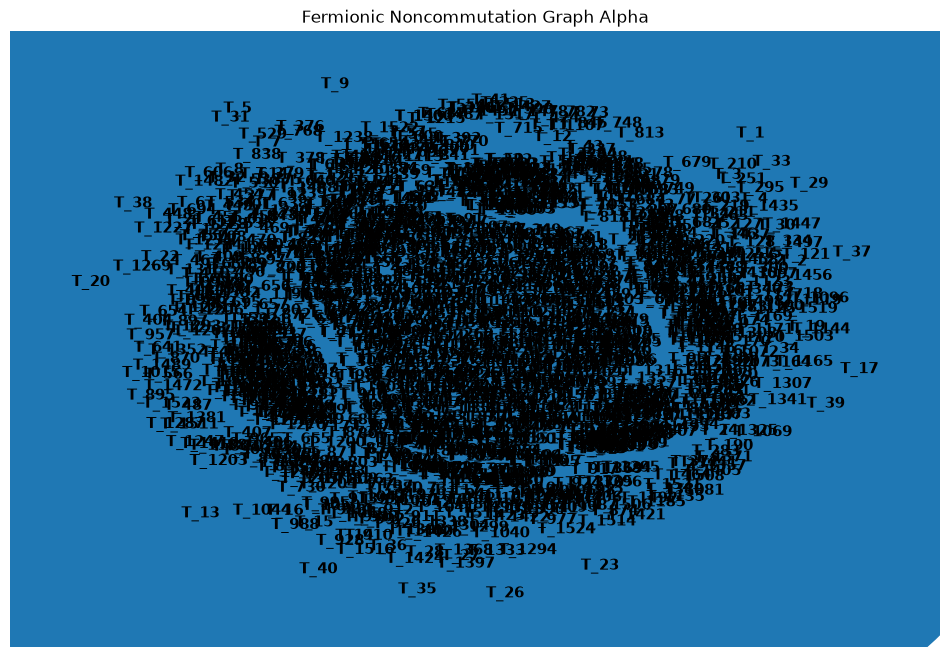

In [2]:
# Cell 2 alpha: Faster H2 / molecular fermionic noncommutation graph
#
# Main idea:
#   1. Use cheap fermionic index rules first.
#   2. Only if rules cannot decide, use exact OpenFermion symbolic commutator.
#   3. Never build sparse/dense matrices.
#
# This cell assumes Cell 1 already defined:
#   hermitian_terms
#   operator_to_string

import time
from collections import Counter

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.utils import commutator
from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# Fermionic key utilities
# ------------------------------------------------------------

def key_modes(key):
    """
    Modes appearing in one OpenFermion monomial key.

    Example:
        ((3, 1), (0, 1), (3, 0), (0, 0)) -> {0, 3}
    """
    return frozenset(mode for mode, action in key)


def key_creations(key):
    """
    Creation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 1)


def key_annihilations(key):
    """
    Annihilation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 0)


def key_net_delta(key):
    """
    Net occupation change caused by a monomial.

    creation contributes +1
    annihilation contributes -1

    For example:
        a_2^dagger a_1^dagger a_3 a_0
    has delta:
        +1 on modes 2 and 1
        -1 on modes 3 and 0
    """
    delta = Counter()

    for mode, action in key:
        if action == 1:
            delta[mode] += 1
        else:
            delta[mode] -= 1

    return delta


def is_diagonal_key(key):
    """
    True if a monomial preserves occupation mode-by-mode.

    Examples:
        a_p^dagger a_p is diagonal.
        a_p^dagger a_q^dagger a_q a_p is diagonal.
        a_p^dagger a_q is not diagonal when p != q.
    """
    delta = key_net_delta(key)
    return all(value == 0 for value in delta.values())


def is_even_key(key):
    """
    Electronic Hamiltonian terms normally have even fermionic parity:
    length 0, 2, or 4.
    """
    return len(key) % 2 == 0


# ------------------------------------------------------------
# Safe monomial-level commutation rules
# ------------------------------------------------------------

def diagonal_key_commutes_with_key(diagonal_key, other_key):
    """
    Safe rule:

    A diagonal occupation operator depending on modes S commutes with another
    monomial if the other monomial has zero net occupation change on every
    mode in S.
    """
    support = key_modes(diagonal_key)
    delta = key_net_delta(other_key)

    return all(delta.get(mode, 0) == 0 for mode in support)


def no_cross_contractions_even_commute(key_a, key_b):
    """
    Safe rule for normal-ordered even fermionic monomials.

    If there are no possible cross contractions:
        annihilations(A) intersect creations(B) = empty
        annihilations(B) intersect creations(A) = empty

    then even monomials commute.

    This catches many cases beyond completely disjoint support.
    """
    if not is_even_key(key_a) or not is_even_key(key_b):
        return False

    a_ann = key_annihilations(key_a)
    a_cre = key_creations(key_a)

    b_ann = key_annihilations(key_b)
    b_cre = key_creations(key_b)

    return a_ann.isdisjoint(b_cre) and b_ann.isdisjoint(a_cre)


def monomial_pair_definitely_commutes(key_a, key_b):
    """
    Return (True, reason) only when we are sure two monomials commute.
    Return (False, None) if the rule cannot decide.

    Important:
        False here does NOT mean noncommuting.
        It only means "unknown; use exact symbolic fallback."
    """
    # Identity commutes with everything.
    if key_a == () or key_b == ():
        return True, "identity"

    # Any monomial commutes with itself.
    if key_a == key_b:
        return True, "same_monomial"

    # Diagonal occupation-like monomials commute with each other.
    if is_diagonal_key(key_a) and is_diagonal_key(key_b):
        return True, "diagonal_diagonal"

    # Diagonal with excitation-like term, if excitation preserves diagonal support.
    if is_diagonal_key(key_a) and diagonal_key_commutes_with_key(key_a, key_b):
        return True, "diagonal_support_preserved"

    if is_diagonal_key(key_b) and diagonal_key_commutes_with_key(key_b, key_a):
        return True, "diagonal_support_preserved"

    # Even monomials with no cross contractions commute.
    if no_cross_contractions_even_commute(key_a, key_b):
        return True, "no_cross_contractions_even"

    return False, None


# ------------------------------------------------------------
# Operator-level metadata and precheck
# ------------------------------------------------------------

def operator_metadata(op):
    """
    Precompute simple structural data for one FermionOperator.
    """
    keys = list(op.terms.keys())

    modes = set()
    for key in keys:
        modes.update(key_modes(key))

    return {
        "is_zero": len(keys) == 0,
        "only_identity": len(keys) == 1 and keys[0] == (),
        "modes": frozenset(modes),
        "is_even": all(is_even_key(key) for key in keys),
        "is_diagonal": all(is_diagonal_key(key) for key in keys),
        "number_of_monomials": len(keys),
    }


def operator_pair_definitely_commutes(A, B, meta_A, meta_B):
    """
    Return (True, reason) only for guaranteed-commuting pairs.
    Return (False, None) when unresolved.
    """
    if meta_A["is_zero"] or meta_B["is_zero"]:
        return True, "zero"

    if meta_A["only_identity"] or meta_B["only_identity"]:
        return True, "identity"

    # Very cheap global rule:
    # disjoint even fermionic operators commute.
    if (
        meta_A["is_even"]
        and meta_B["is_even"]
        and meta_A["modes"].isdisjoint(meta_B["modes"])
    ):
        return True, "disjoint_even_support"

    # Diagonal occupation-like operators commute with each other.
    if meta_A["is_diagonal"] and meta_B["is_diagonal"]:
        return True, "diagonal_diagonal"

    # More detailed but still cheap:
    # if every monomial pair has a safe commuting reason, the sums commute.
    reasons = Counter()

    for key_a in A.terms:
        for key_b in B.terms:
            ok, reason = monomial_pair_definitely_commutes(key_a, key_b)

            if not ok:
                return False, None

            reasons[reason] += 1

    if len(reasons) > 0:
        main_reason = reasons.most_common(1)[0][0]
        return True, f"all_monomial_pairs_{main_reason}"

    return False, None


# ------------------------------------------------------------
# Exact symbolic fallback
# ------------------------------------------------------------

def exact_symbolic_fermionic_commutator(A, B, tol=1e-12):
    """
    Exact symbolic commutator in fermionic algebra.

    This does not build a 2^n matrix.
    """
    C = normal_ordered(commutator(A, B))
    C.compress(abs_tol=tol)
    return C


# ------------------------------------------------------------
# Alpha graph builder
# ------------------------------------------------------------

def build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
):
    """
    Build noncommutation graph using:
        fast safe index rules first,
        exact symbolic OpenFermion fallback only when needed.

    Parameters
    ----------
    hermitian_terms:
        list of FermionOperator terms T_i from Cell 1.

    tol:
        numerical compression tolerance.

    store_commutators:
        False is recommended for large molecules.
        True is useful for H2 debugging, but can be memory-heavy.

    Returns
    -------
    G:
        networkx.Graph

    stats_df:
        pandas.DataFrame with timing and skip counts
    """
    t_start = time.perf_counter()

    G = nx.Graph()
    stats = Counter()

    metadata = [operator_metadata(T) for T in hermitian_terms]

    # Add vertices.
    for i, T in enumerate(hermitian_terms):
        G.add_node(
            i,
            label=f"T_{i}",
            operator=T,
            operator_string=operator_to_string(T),
            number_of_monomials=len(T.terms),
            modes=sorted(metadata[i]["modes"]),
            is_diagonal=metadata[i]["is_diagonal"],
            is_even=metadata[i]["is_even"],
        )

    n = len(hermitian_terms)

    # Pairwise graph construction.
    for i in range(n):
        A = hermitian_terms[i]
        meta_A = metadata[i]

        for j in range(i + 1, n):
            B = hermitian_terms[j]
            meta_B = metadata[j]

            stats["total_pairs"] += 1

            # 1. Fast guaranteed-commuting rules.
            definitely_commutes, reason = operator_pair_definitely_commutes(
                A, B, meta_A, meta_B
            )

            if definitely_commutes:
                stats["pairs_skipped_by_index_rules"] += 1
                stats[f"skip_{reason}"] += 1
                continue

            # 2. Exact symbolic fallback.
            stats["pairs_sent_to_exact_symbolic"] += 1

            Cij = exact_symbolic_fermionic_commutator(A, B, tol=tol)

            if len(Cij.terms) != 0:
                stats["noncommuting_edges"] += 1

                edge_data = {
                    "method": "exact_symbolic_fallback",
                    "meaning": f"[T_{i}, T_{j}] != 0",
                }

                if store_commutators:
                    edge_data["commutator"] = Cij
                    edge_data["commutator_string"] = operator_to_string(Cij)
                else:
                    edge_data["commutator_string"] = (
                        "(not stored; rerun with store_commutators=True)"
                    )

                G.add_edge(i, j, **edge_data)

            else:
                stats["exact_symbolic_found_commuting"] += 1

    elapsed = time.perf_counter() - t_start

    stats["vertices"] = n
    stats["edges"] = G.number_of_edges()
    stats["commuting_pairs"] = stats["total_pairs"] - G.number_of_edges()
    stats["elapsed_seconds"] = elapsed

    stats_df = pd.DataFrame([dict(stats)])

    return G, stats_df


# ------------------------------------------------------------
# Run alpha graph builder
# ------------------------------------------------------------

# For H2 debugging, you can set store_commutators=True.
# For larger molecules, keep this False.
G_alpha, stats_df = build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
)

print("=== Fermionic noncommutation graph alpha summary ===")
display(stats_df)

print("Number of vertices / fermionic terms:", G_alpha.number_of_nodes())
print("Number of noncommuting pairs / edges:", G_alpha.number_of_edges())
print("Is graph bipartite?", nx.is_bipartite(G_alpha))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G_alpha.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G_alpha.degree[i],
            "commutes_with_all": G_alpha.degree[i] == 0,
            "number_of_monomials": data["number_of_monomials"],
            "modes": data["modes"],
            "is_diagonal": data["is_diagonal"],
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df_alpha = pd.DataFrame(vertex_rows)

print("\n=== Alpha vertices: fermionic terms ===")
display(vertex_df_alpha)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G_alpha.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": data["meaning"],
            "method": data["method"],
            "commutator": data["commutator_string"],
        }
    )

edge_df_alpha = pd.DataFrame(edge_rows)

print("\n=== Alpha edges: noncommuting pairs ===")
display(edge_df_alpha)


# ------------------------------------------------------------
# Draw graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.kamada_kawai_layout(G_alpha)

node_labels = {
    i: f"T_{i}"
    for i in G_alpha.nodes()
}

node_sizes = [
    1000 + 250 * G_alpha.degree[i]
    for i in G_alpha.nodes()
]

nx.draw_networkx_nodes(G_alpha, pos, node_size=node_sizes)
nx.draw_networkx_edges(G_alpha, pos, width=1.5)
nx.draw_networkx_labels(
    G_alpha,
    pos,
    labels=node_labels,
    font_size=11,
    font_weight="bold",
)

plt.title("Fermionic Noncommutation Graph Alpha")
plt.axis("off")
plt.show()

=== Fermionic noncommutation graph summary ===
Number of vertices / fermionic terms: 1525
Number of total unordered pairs: 1162050
Number of noncommuting pairs / edges: 639264
Number of commuting pairs: 522786
Is graph bipartite? False

=== Vertices: fermionic terms ===


,vertex,degree,commutes_with_all,fermionic_term
0,T_0,0,True,+9.80901917 I
1,T_1,302,False,-3.21119257 a_0^dagger a_0
2,T_2,590,False,+0.17369672 a_0^dagger a_4 + +0.17369672 a_4^dagger a_0
3,T_3,590,False,+0.04879764 a_0^dagger a_8 + +0.04879764 a_8^dagger a_0
4,T_4,590,False,-0.03288405 a_0^dagger a_12 + -0.03288405 a_12^dagger a_0
...,...,...,...,...
1520,T_1520,918,False,+0.17963264 a_14^dagger a_13^dagger a_15 a_12 + +0.17963264 a_15^dagger a_12^dagger a_14 a_13
1521,T_1521,529,False,-0.46345553 a_15^dagger a_12^dagger a_15 a_12
1522,T_1522,529,False,-0.46345553 a_14^dagger a_13^dagger a_14 a_13
1523,T_1523,495,False,-0.28382289 a_15^dagger a_13^dagger a_15 a_13



=== Edges: noncommuting pairs ===


,source,target,meaning,commutator
0,T_1,T_2,"[T_1, T_2] != 0",-0.55777363 a_0^dagger a_4 + +0.55777363 a_4^dagger a_0
1,T_1,T_3,"[T_1, T_3] != 0",-0.15669863 a_0^dagger a_8 + +0.15669863 a_8^dagger a_0
2,T_1,T_4,"[T_1, T_4] != 0",+0.10559701 a_0^dagger a_12 + -0.10559701 a_12^dagger a_0
3,T_1,T_42,"[T_1, T_42] != 0",+0.26341107 a_1^dagger a_0^dagger a_4 a_1 + -0.26341107 a_4^dagger a_1^dagger a_1 a_0
4,T_1,T_43,"[T_1, T_43] != 0",-0.02127608 a_1^dagger a_0^dagger a_8 a_1 + +0.02127608 a_8^dagger a_1^dagger a_1 a_0
...,...,...,...,...
639259,T_1516,T_1520,"[T_1516, T_1520] != 0",-0.05731117 a_14^dagger a_13^dagger a_11^dagger a_15 a_12 a_11 + +0.05731117 a_15^dagger a_12^dagger a_11^dagger a_14 a_13 a_11
639260,T_1517,T_1518,"[T_1517, T_1518] != 0",-0.08274381 a_13^dagger a_12^dagger a_15 a_14 + +0.08274381 a_15^dagger a_14^dagger a_13 a_12
639261,T_1518,T_1524,"[T_1518, T_1524] != 0",-0.10531162 a_13^dagger a_12^dagger a_15 a_14 + +0.10531162 a_15^dagger a_14^dagger a_13 a_12
639262,T_1520,T_1521,"[T_1520, T_1521] != 0",+0.08325174 a_14^dagger a_13^dagger a_15 a_12 + -0.08325174 a_15^dagger a_12^dagger a_14 a_13


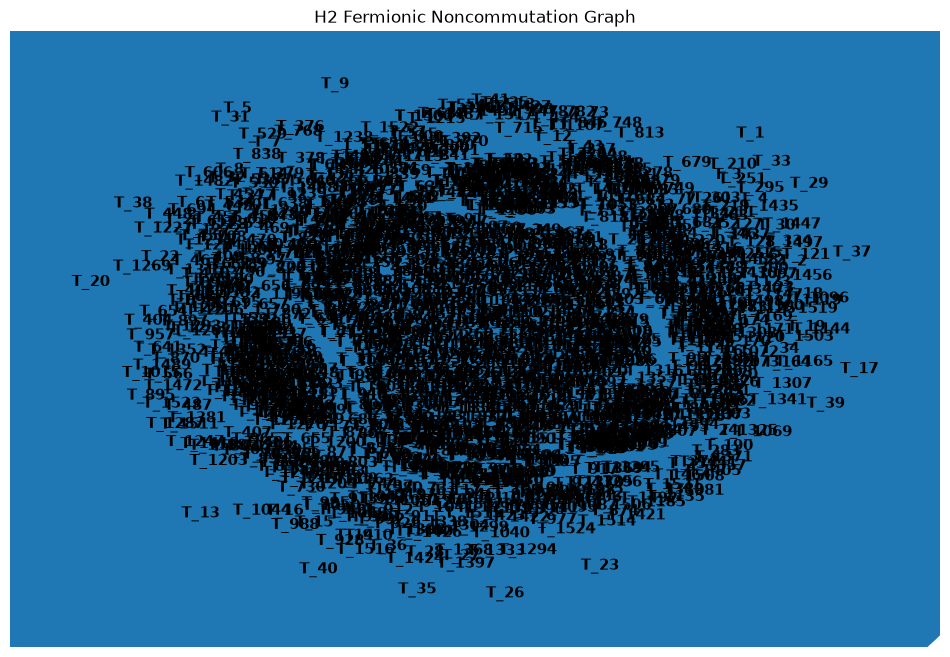

In [3]:
# Cell 2: Build the H2 fermionic noncommutation graph

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


def fermionic_commutator(A, B, tol=1e-12):
    """
    Compute [A, B] = AB - BA directly in the fermionic algebra.
    """
    C = normal_ordered(A * B - B * A)
    C.compress(abs_tol=tol)
    return C


def commute(A, B, tol=1e-12):
    """
    Return True if [A, B] = 0.
    """
    C = fermionic_commutator(A, B, tol=tol)
    return len(C.terms) == 0


# ------------------------------------------------------------
# Build noncommutation graph
# ------------------------------------------------------------
# Vertex i = Hermitian fermionic term T_i
# Edge (i, j) exists if [T_i, T_j] != 0

G = nx.Graph()

for i, T in enumerate(hermitian_terms):
    G.add_node(
        i,
        label=f"T_{i}",
        operator=T,
        operator_string=operator_to_string(T),
        number_of_monomials=len(T.terms),
    )

for i in range(len(hermitian_terms)):
    for j in range(i + 1, len(hermitian_terms)):
        Cij = fermionic_commutator(hermitian_terms[i], hermitian_terms[j])

        if len(Cij.terms) != 0:
            G.add_edge(
                i,
                j,
                commutator=Cij,
                commutator_string=operator_to_string(Cij),
            )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

n_vertices = G.number_of_nodes()
n_total_pairs = n_vertices * (n_vertices - 1) // 2
n_noncommuting_pairs = G.number_of_edges()
n_commuting_pairs = n_total_pairs - n_noncommuting_pairs

print("=== Fermionic noncommutation graph summary ===")
print("Number of vertices / fermionic terms:", n_vertices)
print("Number of total unordered pairs:", n_total_pairs)
print("Number of noncommuting pairs / edges:", n_noncommuting_pairs)
print("Number of commuting pairs:", n_commuting_pairs)
print("Is graph bipartite?", nx.is_bipartite(G))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G.degree[i],
            "commutes_with_all": G.degree[i] == 0,
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df = pd.DataFrame(vertex_rows)

print("\n=== Vertices: fermionic terms ===")
display(vertex_df)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": f"[T_{i}, T_{j}] != 0",
            "commutator": data["commutator_string"],
        }
    )

edge_df = pd.DataFrame(edge_rows)

print("\n=== Edges: noncommuting pairs ===")
display(edge_df)


# ------------------------------------------------------------
# Draw graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.kamada_kawai_layout(G)

node_labels = {
    i: f"T_{i}"
    for i in G.nodes()
}

node_sizes = [
    1000 + 250 * G.degree[i]
    for i in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=1.5)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=11, font_weight="bold")

plt.title("H2 Fermionic Noncommutation Graph")
plt.axis("off")
plt.show()

In [4]:
print("Same edge set?")
print(set(G.edges()) == set(G_alpha.edges()))

Same edge set?
True


In [5]:
# Cell 3: Color graph, build commuting blocks, map JW/BK, verify commutation

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from openfermion.ops import FermionOperator
from openfermion.transforms import normal_ordered, jordan_wigner, bravyi_kitaev

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# 1. Color the noncommutation graph
# ------------------------------------------------------------
# Since edges mean noncommutation, each color class is a commuting group.

coloring = nx.coloring.greedy_color(G, strategy="largest_first")

color_groups = {}

for node, color in coloring.items():
    color_groups.setdefault(color, []).append(node)

for color in color_groups:
    color_groups[color] = sorted(color_groups[color])

color_names = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "gray",
]

color_name = {
    color: color_names[color] if color < len(color_names) else f"color_{color}"
    for color in color_groups
}

num_grouped_terms = sum(len(nodes) for nodes in color_groups.values())

print("Number of fermionic terms / vertices:", G.number_of_nodes())
print("Number of colors / commuting groups:", len(color_groups))
print("Number of grouped terms:", num_grouped_terms)

assert num_grouped_terms == G.number_of_nodes()


# ------------------------------------------------------------
# 2. Verify each color group is mutually commuting
# ------------------------------------------------------------

def verify_commuting_group(nodes, tol=1e-12):
    for i, j in combinations(nodes, 2):
        A = G.nodes[i]["operator"]
        B = G.nodes[j]["operator"]

        if not commute(A, B, tol=tol):
            return False

    return True


group_summary_rows = []

for color, nodes in sorted(color_groups.items()):
    group_summary_rows.append(
        {
            "color_id": color,
            "color_name": color_name[color],
            "number_of_terms": len(nodes),
            "vertices": [f"T_{i}" for i in nodes],
            "verified_mutually_commuting": verify_commuting_group(nodes),
        }
    )

group_summary_df = pd.DataFrame(group_summary_rows)

print("\n=== Commuting groups from graph coloring ===")
display(group_summary_df)


# ------------------------------------------------------------
# 3. Build Hamiltonian pieces by color
# ------------------------------------------------------------

H_by_color = {}

for color, nodes in sorted(color_groups.items()):
    H_color = FermionOperator.zero()

    for node in nodes:
        H_color += G.nodes[node]["operator"]

    H_color = normal_ordered(H_color)
    H_color.compress(abs_tol=1e-12)

    H_by_color[color] = H_color


color_block_rows = []

for color, nodes in sorted(color_groups.items()):
    for local_index, node in enumerate(nodes, start=1):
        color_block_rows.append(
            {
                "color_block": f"H_{color_name[color]}",
                "local_term_name": f"{color_name[color][0].upper()}_{local_index}",
                "vertex": f"T_{node}",
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

color_block_df = pd.DataFrame(color_block_rows)

print("\n=== Which T_i belongs to which color block ===")
display(color_block_df)


print("\n=== Hamiltonian split by commuting color groups ===")

for color, H_color in H_by_color.items():
    nodes = color_groups[color]

    print("\n" + "=" * 80)
    print(f"H_{color_name[color]} consists of:")
    print(" + ".join([f"T_{node}" for node in nodes]))

    print(f"\nSummed operator H_{color_name[color]} =")
    print(H_color)


# ------------------------------------------------------------
# 4. Trotter ordering induced by color groups
# ------------------------------------------------------------

trotter_order = []

for color, nodes in sorted(color_groups.items()):
    for node in nodes:
        trotter_order.append(node)

print("\n=== Trotter order by commuting color groups ===")
print([f"T_{i}" for i in trotter_order])


# ------------------------------------------------------------
# 5. Helper functions for JW/BK output
# ------------------------------------------------------------

def sort_qubit_key(term):
    return (len(term), term)


def format_qubit_term(term):
    if term == ():
        return "I"

    return " ".join([f"{pauli}{qubit}" for qubit, pauli in term])


def qubit_coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def qubit_operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_qubit_key(item[0])):
        pieces.append(f"{qubit_coeff_to_str(coeff, digits)} {format_qubit_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def apply_bk(op, n_qubits):
    try:
        return bravyi_kitaev(op, n_qubits=n_qubits)
    except TypeError:
        return bravyi_kitaev(op, n_qubits)


def qubit_commutator(A, B, tol=1e-12):
    C = A * B - B * A
    C.compress(abs_tol=tol)
    return C


def qubit_commute(A, B, tol=1e-12):
    C = qubit_commutator(A, B, tol=tol)
    return len(C.terms) == 0


n_qubits = molecule.n_qubits

print("\nNumber of qubits / spin orbitals:", n_qubits)


# ------------------------------------------------------------
# 6. Map each fermionic vertex T_i to JW(T_i) and BK(T_i)
# ------------------------------------------------------------

mapped_rows = []

for node in sorted(G.nodes()):
    T_i = G.nodes[node]["operator"]

    JW_T_i = jordan_wigner(T_i)
    JW_T_i.compress(abs_tol=1e-12)

    BK_T_i = apply_bk(T_i, n_qubits=n_qubits)
    BK_T_i.compress(abs_tol=1e-12)

    G.nodes[node]["JW_operator"] = JW_T_i
    G.nodes[node]["BK_operator"] = BK_T_i
    G.nodes[node]["JW_operator_string"] = qubit_operator_to_string(JW_T_i)
    G.nodes[node]["BK_operator_string"] = qubit_operator_to_string(BK_T_i)

    node_color = coloring[node]
    node_color_name = color_name[node_color]

    mapped_rows.append(
        {
            "color": node_color_name,
            "vertex": f"T_{node}",
            "fermionic_term": G.nodes[node]["operator_string"],
            "number_of_JW_Pauli_strings": len(JW_T_i.terms),
            "JW_transform": qubit_operator_to_string(JW_T_i),
            "number_of_BK_Pauli_strings": len(BK_T_i.terms),
            "BK_transform": qubit_operator_to_string(BK_T_i),
        }
    )

mapped_terms_df = pd.DataFrame(mapped_rows)

print("\n=== Fermionic terms mapped to JW and BK ===")
display(mapped_terms_df)


# ------------------------------------------------------------
# 7. Map each color block H_color to JW and BK
# ------------------------------------------------------------

JW_by_color = {}
BK_by_color = {}

block_rows = []

for color, H_color in sorted(H_by_color.items()):
    JW_color = jordan_wigner(H_color)
    JW_color.compress(abs_tol=1e-12)

    BK_color = apply_bk(H_color, n_qubits=n_qubits)
    BK_color.compress(abs_tol=1e-12)

    JW_by_color[color] = JW_color
    BK_by_color[color] = BK_color

    block_rows.append(
        {
            "color_block": f"H_{color_name[color]}",
            "fermionic_vertices": " + ".join([f"T_{node}" for node in color_groups[color]]),
            "number_of_fermionic_terms": len(color_groups[color]),
            "number_of_JW_Pauli_strings": len(JW_color.terms),
            "JW_block": qubit_operator_to_string(JW_color),
            "number_of_BK_Pauli_strings": len(BK_color.terms),
            "BK_block": qubit_operator_to_string(BK_color),
        }
    )

block_map_df = pd.DataFrame(block_rows)

print("\n=== Color blocks mapped to JW and BK ===")
display(block_map_df)


# ------------------------------------------------------------
# 8. Verify same-color terms commute after JW and BK
# ------------------------------------------------------------

verification_rows = []

for color, nodes in sorted(color_groups.items()):
    for i, j in combinations(nodes, 2):
        Ti = G.nodes[i]["operator"]
        Tj = G.nodes[j]["operator"]

        JW_Ti = G.nodes[i]["JW_operator"]
        JW_Tj = G.nodes[j]["JW_operator"]

        BK_Ti = G.nodes[i]["BK_operator"]
        BK_Tj = G.nodes[j]["BK_operator"]

        verification_rows.append(
            {
                "color_group": color_name[color],
                "pair": f"T_{i}, T_{j}",
                "fermionic_commute": commute(Ti, Tj),
                "JW_commute": qubit_commute(JW_Ti, JW_Tj),
                "BK_commute": qubit_commute(BK_Ti, BK_Tj),
            }
        )

verification_df = pd.DataFrame(verification_rows)

print("\n=== Verify commuting groups after JW/BK mapping ===")
display(verification_df)

Number of fermionic terms / vertices: 1525
Number of colors / commuting groups: 137
Number of grouped terms: 1525

=== Commuting groups from graph coloring ===


,color_id,color_name,number_of_terms,vertices,verified_mutually_commuting
0,0,red,13,"[T_0, T_45, T_80, T_89, T_411, T_1054, T_1078, T_1429, T_1438, T_1439, T_1475, T_1518, T_1520]",True
1,1,blue,12,"[T_46, T_90, T_167, T_416, T_698, T_727, T_1211, T_1430, T_1440, T_1457, T_1502, T_1505]",True
2,2,green,10,"[T_47, T_91, T_254, T_419, T_699, T_728, T_1077, T_1110, T_1132, T_1208]",True
3,3,orange,14,"[T_48, T_92, T_337, T_404, T_700, T_729, T_1111, T_1121, T_1133, T_1203, T_1355, T_1366, T_1472, T_1523]",True
4,4,purple,13,"[T_53, T_85, T_179, T_490, T_878, T_907, T_1069, T_1433, T_1459, T_1490, T_1510, T_1513, T_1519]",True
...,...,...,...,...,...
132,132,color_132,10,"[T_455, T_538, T_682, T_818, T_992, T_1048, T_1120, T_1215, T_1263, T_1498]",True
133,133,color_133,4,"[T_122, T_716, T_1147, T_1359]",True
134,134,color_134,5,"[T_128, T_219, T_513, T_721, T_789]",True
135,135,color_135,4,"[T_211, T_783, T_1097, T_1326]",True



=== Which T_i belongs to which color block ===


,color_block,local_term_name,vertex,fermionic_term
0,H_red,R_1,T_0,+9.80901917 I
1,H_red,R_2,T_45,-0.13589373 a_1^dagger a_0^dagger a_3 a_2 + -0.13589373 a_3^dagger a_2^dagger a_1 a_0
2,H_red,R_3,T_80,+0.04334044 a_2^dagger a_0^dagger a_6 a_4 + +0.04334044 a_6^dagger a_4^dagger a_2 a_0
3,H_red,R_4,T_89,+0.13589373 a_2^dagger a_1^dagger a_3 a_0 + +0.13589373 a_3^dagger a_0^dagger a_2 a_1
4,H_red,R_5,T_411,+0.04334044 a_3^dagger a_1^dagger a_7 a_5 + +0.04334044 a_7^dagger a_5^dagger a_3 a_1
...,...,...,...,...
1520,H_color_135,C_4,T_1326,-0.01499167 a_10^dagger a_6^dagger a_14 a_6 + -0.01499167 a_14^dagger a_6^dagger a_10 a_6
1521,H_color_136,C_1,T_215,+0.01427734 a_8^dagger a_0^dagger a_8 a_4 + +0.01427734 a_8^dagger a_4^dagger a_8 a_0
1522,H_color_136,C_2,T_300,+0.00599025 a_12^dagger a_0^dagger a_12 a_4 + +0.00599025 a_12^dagger a_4^dagger a_12 a_0
1523,H_color_136,C_3,T_786,-0.01472382 a_10^dagger a_2^dagger a_10 a_6 + -0.01472382 a_10^dagger a_6^dagger a_10 a_2



=== Hamiltonian split by commuting color groups ===

H_red consists of:
T_0 + T_45 + T_80 + T_89 + T_411 + T_1054 + T_1078 + T_1429 + T_1438 + T_1439 + T_1475 + T_1518 + T_1520

Summed operator H_red =
9.809019170392693 [] +
-0.1358937323500319 [1^ 0^ 3 2] +
0.043340441787220345 [2^ 0^ 6 4] +
0.1358937323500319 [2^ 1^ 3 0] +
0.1358937323500319 [3^ 0^ 2 1] +
0.043340441787220345 [3^ 1^ 7 5] +
-0.1358937323500319 [3^ 2^ 1 0] +
-0.12077082610150218 [5^ 4^ 7 6] +
0.04334044178722034 [6^ 4^ 2 0] +
0.12077082610150218 [6^ 5^ 7 4] +
0.12077082610150218 [7^ 4^ 6 5] +
0.04334044178722034 [7^ 5^ 3 1] +
-0.12077082610150218 [7^ 6^ 5 4] +
-0.12323044788252352 [9^ 8^ 11 10] +
-0.06478259086847203 [10^ 8^ 14 12] +
0.12323044788252352 [10^ 9^ 11 8] +
0.12323044788252352 [11^ 8^ 10 9] +
-0.06478259086847203 [11^ 9^ 15 13] +
-0.12323044788252352 [11^ 10^ 9 8] +
-0.1796326352304074 [13^ 12^ 15 14] +
-0.06478259086847202 [14^ 12^ 10 8] +
0.1796326352304074 [14^ 13^ 15 12] +
0.1796326352304074 [15^ 12^ 1

,color,vertex,fermionic_term,number_of_JW_Pauli_strings,JW_transform,number_of_BK_Pauli_strings,BK_transform
0,red,T_0,+9.80901917 I,1,+9.80901917 I,1,+9.80901917 I
1,color_64,T_1,-3.21119257 a_0^dagger a_0,2,-1.60559628 I + +1.60559628 Z0,2,-1.60559628 I + +1.60559628 Z0
2,color_78,T_2,+0.17369672 a_0^dagger a_4 + +0.17369672 a_4^dagger a_0,2,+0.08684836 X0 Z1 Z2 Z3 X4 + +0.08684836 Y0 Z1 Z2 Z3 Y4,2,+0.08684836 X0 X1 Y3 Y4 X5 + -0.08684836 Y0 X1 Y3 X4 X5
3,color_76,T_3,+0.04879764 a_0^dagger a_8 + +0.04879764 a_8^dagger a_0,2,+0.02439882 X0 Z1 Z2 Z3 Z4 Z5 Z6 Z7 X8 + +0.02439882 Y0 Z1 Z2 Z3 Z4 Z5 Z6 Z7 Y8,2,+0.02439882 X0 X1 X3 Y7 Y8 X9 X11 + -0.02439882 Y0 X1 X3 Y7 X8 X9 X11
4,color_109,T_4,-0.03288405 a_0^dagger a_12 + -0.03288405 a_12^dagger a_0,2,-0.01644202 X0 Z1 Z2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 X12 + -0.01644202 Y0 Z1 Z2 Z3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Z11 Y12,2,-0.01644202 X0 X1 X3 Y7 Z11 Y12 X13 + +0.01644202 Y0 X1 X3 Y7 Z11 X12 X13
...,...,...,...,...,...,...,...
1520,red,T_1520,+0.17963264 a_14^dagger a_13^dagger a_15 a_12 + +0.17963264 a_15^dagger a_12^dagger a_14 a_13,8,-0.02245408 X12 X13 X14 X15 + -0.02245408 X12 X13 Y14 Y15 + -0.02245408 X12 Y13 X14 Y15 + +0.02245408 X12 Y13 Y14 X15 + +0.02245408 Y12 X13 X14 Y15 + -0.02245408 Y12 X13 Y14 X15 + -0.02245408 Y12 Y13 X14 X15 + -0.02245408 Y12 Y13 Y14 Y15,8,-0.02245408 X12 X14 + -0.02245408 Y12 Y14 + +0.02245408 X12 Z13 X14 + +0.02245408 Y12 Z13 Y14 + -0.02245408 Z7 Z11 X12 X14 Z15 + -0.02245408 Z7 Z11 Y12 Y14 Z15 + +0.02245408 Z7 Z11 X12 Z13 X14 Z15 + +0.02245408 Z7 Z11 Y12 Z13 Y14 Z15
1521,color_34,T_1521,-0.46345553 a_15^dagger a_12^dagger a_15 a_12,4,+0.11586388 I + -0.11586388 Z12 + -0.11586388 Z15 + +0.11586388 Z12 Z15,4,+0.11586388 I + -0.11586388 Z12 + -0.11586388 Z7 Z11 Z13 Z14 Z15 + +0.11586388 Z7 Z11 Z12 Z13 Z14 Z15
1522,color_41,T_1522,-0.46345553 a_14^dagger a_13^dagger a_14 a_13,4,+0.11586388 I + -0.11586388 Z13 + -0.11586388 Z14 + +0.11586388 Z13 Z14,4,+0.11586388 I + -0.11586388 Z14 + -0.11586388 Z12 Z13 + +0.11586388 Z12 Z13 Z14
1523,orange,T_1523,-0.28382289 a_15^dagger a_13^dagger a_15 a_13,4,+0.07095572 I + -0.07095572 Z13 + -0.07095572 Z15 + +0.07095572 Z13 Z15,4,+0.07095572 I + -0.07095572 Z12 Z13 + +0.07095572 Z7 Z11 Z12 Z14 Z15 + -0.07095572 Z7 Z11 Z13 Z14 Z15



=== Color blocks mapped to JW and BK ===


,color_block,fermionic_vertices,number_of_fermionic_terms,number_of_JW_Pauli_strings,JW_block,number_of_BK_Pauli_strings,BK_block
0,H_red,T_0 + T_45 + T_80 + T_89 + T_411 + T_1054 + T_1078 + T_1429 + T_1438 + T_1439 + T_1475 + T_1518 + T_1520,13,49,+9.80901917 I + -0.03397343 X0 X1 Y2 Y3 + +0.03397343 X0 Y1 Y2 X3 + +0.03397343 Y0 X1 X2 Y3 + -0.03397343 Y0 Y1 X2 X3 + -0.03019271 X4 X5 Y6 Y7 + +0.03019271 X4 Y5 Y6 X7 + +0.03019271 Y4 X5 X6 Y7 + -0.03019271 Y4 Y5 X6 X7 + -0.03080761 X8 X9 Y10 Y11 + +0.03080761 X8 Y9 Y10 X11 + +0.03080761 Y8 X9 X10 Y11 + -0.03080761 Y8 Y9 X10 X11 + -0.04490816 X12 X13 Y14 Y15 + +0.04490816 X12 Y13 Y14 X15 + +0.04490816 Y12 X13 X14 Y15 + -0.04490816 Y12 Y13 X14 X15 + -0.00541756 X0 Z1 X2 X4 Z5 X6 + +0.00541756 X0 Z1 X2 Y4 Z5 Y6 + -0.00541756 X0 Z1 Y2 X4 Z5 Y6 + -0.00541756 X0 Z1 Y2 Y4 Z5 X6 + -0.00541756 Y0 Z1 X2 X4 Z5 Y6 + -0.00541756 Y0 Z1 X2 Y4 Z5 X6 + +0.00541756 Y0 Z1 Y2 X4 Z5 X6 + -0.00541756 Y0 Z1 Y2 Y4 Z5 Y6 + -0.00541756 X1 Z2 X3 X5 Z6 X7 + +0.00541756 X1 Z2 X3 Y5 Z6 Y7 + -0.00541756 X1 Z2 Y3 X5 Z6 Y7 + -0.00541756 X1 Z2 Y3 Y5 Z6 X7 + -0.00541756 Y1 Z2 X3 X5 Z6 Y7 + -0.00541756 Y1 Z2 X3 Y5 Z6 X7 + +0.00541756 Y1 Z2 Y3 X5 Z6 X7 + -0.00541756 Y1 Z2 Y3 Y5 Z6 Y7 + +0.00809782 X8 Z9 X10 X12 Z13 X14 + -0.00809782 X8 Z9 X10 Y12 Z13 Y14 + +0.00809782 X8 Z9 Y10 X12 Z13 Y14 + +0.00809782 X8 Z9 Y10 Y12 Z13 X14 + +0.00809782 Y8 Z9 X10 X12 Z13 Y14 + +0.00809782 Y8 Z9 X10 Y12 Z13 X14 + -0.00809782 Y8 Z9 Y10 X12 Z13 X14 + +0.00809782 Y8 Z9 Y10 Y12 Z13 Y14 + +0.00809782 X9 Z10 X11 X13 Z14 X15 + -0.00809782 X9 Z10 X11 Y13 Z14 Y15 + +0.00809782 X9 Z10 Y11 X13 Z14 Y15 + +0.00809782 X9 Z10 Y11 Y13 Z14 X15 + +0.00809782 Y9 Z10 X11 X13 Z14 Y15 + +0.00809782 Y9 Z10 X11 Y13 Z14 X15 + -0.00809782 Y9 Z10 Y11 X13 Z14 X15 + +0.00809782 Y9 Z10 Y11 Y13 Z14 Y15,49,+9.80901917 I + +0.03397343 X0 Z1 X2 + +0.03397343 Y0 Z1 Y2 + -0.00541756 Y1 Y5 Z7 + +0.03019271 X4 Z5 X6 + +0.03019271 Y4 Z5 Y6 + +0.03080761 X8 Z9 X10 + +0.03080761 Y8 Z9 Y10 + +0.04490816 X12 Z13 X14 + +0.04490816 Y12 Z13 Y14 + +0.03397343 X0 Z1 X2 Z3 + +0.03397343 Y0 Z1 Y2 Z3 + -0.00541756 X1 Z2 X5 Z6 + +0.00809782 Z7 Y9 Y13 Z15 + +0.03080761 X8 Z9 X10 Z11 + +0.03080761 Y8 Z9 Y10 Z11 + +0.00809782 X9 Z10 X13 Z14 + -0.00541756 Z0 X1 Z3 X5 Z6 + -0.00541756 Z0 X1 Z4 X5 Z7 + -0.00541756 Y1 Z3 Z4 Y5 Z6 + +0.03019271 Z3 X4 Z5 X6 Z7 + +0.03019271 Z3 Y4 Z5 Y6 Z7 + +0.00809782 Z8 X9 Z11 X13 Z14 + +0.00809782 Y9 Z11 Z12 Y13 Z14 + -0.00541756 X0 Y1 X2 X4 Y5 X6 + +0.00541756 X0 Y1 X2 Y4 Y5 Y6 + -0.00541756 X0 Y1 Y2 X4 Y5 Y6 + -0.00541756 X0 Y1 Y2 Y4 Y5 X6 + -0.00541756 Y0 Y1 X2 X4 Y5 Y6 + -0.00541756 Y0 Y1 X2 Y4 Y5 X6 + +0.00541756 Y0 Y1 Y2 X4 Y5 X6 + -0.00541756 Y0 Y1 Y2 Y4 Y5 Y6 + -0.00541756 Z0 Y1 Z2 Z3 Y5 Z7 + -0.00541756 Z0 Y1 Z2 Z4 Y5 Z6 + -0.00541756 X1 Z2 Z3 Z4 X5 Z7 + +0.00809782 Z7 Z8 X9 Z12 X13 Z15 + +0.04490816 Z7 Z11 X12 Z13 X14 Z15 + +0.04490816 Z7 Z11 Y12 Z13 Y14 Z15 + +0.00809782 X8 Y9 X10 X12 Y13 X14 + -0.00809782 X8 Y9 X10 Y12 Y13 Y14 + +0.00809782 X8 Y9 Y10 X12 Y13 Y14 + +0.00809782 X8 Y9 Y10 Y12 Y13 X14 + +0.00809782 Y8 Y9 X10 X12 Y13 Y14 + +0.00809782 Y8 Y9 X10 Y12 Y13 X14 + -0.00809782 Y8 Y9 Y10 X12 Y13 X14 + +0.00809782 Y8 Y9 Y10 Y12 Y13 Y14 + +0.00809782 Z8 Y9 Z10 Z12 Y13 Z14 + +0.00809782 Z7 Z8 Y9 Z10 Z11 Y13 Z15 + +0.00809782 Z7 X9 Z10 Z11 Z12 X13 Z15
1,H_blue,T_46 + T_90 + T_167 + T_416 + T_698 + T_727 + T_1211 + T_1430 + T_1440 + T_1457 + T_1502 + T_1505,12,48,-0.01387415 X0 X1 X3 Z4 Z5 X6 + -0.01387415 X0 Y1 Y3 Z4 Z5 X6 + -0.00403990 X0 Z1 X2 X4 Z5 X6 + -0.00403990 X0 Z1 X2 Y4 Z5 Y6 + -0.00403990 X0 Z1 Y2 X4 Z5 Y6 + +0.00403990 X0 Z1 Y2 Y4 Z5 X6 + -0.01387415 Y0 X1 X3 Z4 Z5 Y6 + -0.01387415 Y0 Y1 Y3 Z4 Z5 Y6 + +0.00403990 Y0 Z1 X2 X4 Z5 Y6 + -0.00403990 Y0 Z1 X2 Y4 Z5 X6 + -0.00403990 Y0 Z1 Y2 X4 Z5 X6 + -0.00403990 Y0 Z1 Y2 Y4 Z5 Y6 + -0.00239982 X1 Z2 X3 X9 Z10 X11 + +0.00239982 X1 Z2 X3 Y9 Z10 Y11 + -0.00239982 X1 Z2 Y3 X9 Z10 Y11 + -0.00239982 X1 Z2 Y3 Y9 Z10 X11 + -0.00239982 Y1 Z2 X3 X9 Z10 Y11 + -0.00239982 Y1 Z2 X3 Y9 Z10 X11 + +0.


=== Verify commuting groups after JW/BK mapping ===


,color_group,pair,fermionic_commute,JW_commute,BK_commute
0,red,"T_0, T_45",True,True,True
1,red,"T_0, T_80",True,True,True
2,red,"T_0, T_89",True,True,True
3,red,"T_0, T_411",True,True,True
4,red,"T_0, T_1054",True,True,True
...,...,...,...,...,...
8625,color_136,"T_215, T_786",True,True,True
8626,color_136,"T_215, T_849",True,True,True
8627,color_136,"T_300, T_786",True,True,True
8628,color_136,"T_300, T_849",True,True,True


In [6]:
# Find duplicated JW Pauli strings across fermionic terms T_i

from collections import defaultdict
import pandas as pd

pauli_usage = defaultdict(list)

for node in sorted(G.nodes()):
    JW_T = G.nodes[node]["JW_operator"]

    for pauli_key, coeff in JW_T.terms.items():
        pauli_string = format_qubit_term(pauli_key)

        pauli_usage[pauli_string].append(
            {
                "vertex": f"T_{node}",
                "coefficient": coeff,
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

duplicate_rows = []

for pauli_string, appearances in pauli_usage.items():
    if len(appearances) > 1:
        duplicate_rows.append(
            {
                "JW_Pauli_string": pauli_string,
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "coefficients": [x["coefficient"] for x in appearances],
            }
        )

duplicate_jw_df = pd.DataFrame(duplicate_rows)
duplicate_jw_df = duplicate_jw_df.sort_values(
    "number_of_appearances",
    ascending=False
).reset_index(drop=True)

print("Total JW Pauli-string appearances:", sum(len(G.nodes[node]["JW_operator"].terms) for node in G.nodes()))
print("Number of unique JW Pauli strings:", len(pauli_usage))
print("Number of duplicated JW Pauli strings:", len(duplicate_jw_df))

display(duplicate_jw_df)

Total JW Pauli-string appearances: 10129
Number of unique JW Pauli strings: 4665
Number of duplicated JW Pauli strings: 3873


,JW_Pauli_string,number_of_appearances,appears_in_vertices,coefficients
0,I,137,"[T_0, T_1, T_5, T_9, T_13, T_17, T_20, T_23, T_26, T_29, T_31, T_33, T_35, T_37, T_38, T_39, T_40, T_41, T_73, T_93, T_121, T_140, T_164, T_190, T_210, T_235, T_251, T_283, T_295, T_326, T_334, T_372, T_376, T_404, T_424, T_448, T_467, T_487, T_513, T_529, T_554, T_566, T_598, T_606, T_637, T_641, T_654, T_679, T_694, T_715, T_730, T_748, T_768, T_782, T_802, T_813, T_838, T_845, T_870, T_874, T_895, T_910, T_928, T_943, T_957, T_977, T_988, T_1008, T_1015, T_1040, T_1044, T_1051, T_1069, T_1081, T_1096, T_1107, T_1119, T_1135, T_1144, T_1159, T_1165, T_1185, T_1188, T_1203, T_1215, T_1227, T_1238, T_1247, T_1263, T_1269, T_1284, T_1287, T_1294, T_1307, T_1315, T_1325, T_1333, T_1341, T_1352, T_1357, ...]","[9.809019170392693, -1.6055962841405997, -1.6055962841405997, -1.4741070361682818, -1.4741070361682818, -1.3545614334483596, -1.3545614334483596, -1.2687017050214053, -1.2687017050214053, -1.1396487675704, -1.1396487675704, -0.946501779028047, -0.946501779028047, -0.7411310056686922, -0.7411310056686922, -0.5502101009645675, -0.5502101009645675, 0.11270387195821018, 0.057684780408594066, 0.09165821349610204, 0.06569931089245566, 0.08770376258302984, 0.07453183519338955, 0.09300586295574073, 0.08004017047812298, 0.09533124246363198, 0.08301702670118834, 0.09431221622516366, 0.09033029905205632, 0.10059907345293344, 0.11105496696026733, 0.12341241483900685, 0.09165821349610204, 0.057684780408594066, 0.08770376258302984, 0.06569931089245566, 0.09300586295574073, 0.07453183519338955, 0.09533124246363198, 0.08004017047812298, 0.09431221622516366, 0.08301702670118834, 0.10059907345293344, 0.09033029905205632, 0.12341241483900685, 0.11105496696026733, 0.09641679408742095, 0.05797165377438526, 0.08794741825418989, 0.06722855400228217, 0.08931481644982459, 0.07413483916174517, 0.09111971436394185, 0.07904466500335036, 0.09310537856502274, 0.08861163659197253, 0.10204599782024362, 0.09134907389756124, 0.10074627123263265, 0.08794741825418989, 0.05797165377438526, 0.08931481644982459, 0.06722855400228217, 0.09111971436394185, 0.07413483916174517, 0.09310537856502274, 0.07904466500335036, 0.10204599782024362, 0.08861163659197253, 0.10074627123263265, 0.09134907389756124, 0.09221343486777125, 0.058232449224432735, 0.08842515574980828, 0.06936311800444721, 0.08978155889294884, 0.07585959119418006, 0.09398220581907771, 0.08101126855943731, 0.09430955499502187, 0.0864283919184713, 0.096625054378041, 0.08842515574980828, 0.058232449224432735, 0.08978155889294884, 0.06936311800444721, 0.09398220581907771, 0.07585959119418006, 0.09430955499502187, 0.08101126855943731, 0.096625054378041, 0.0864283919184713, 0.0940635976638803, 0.06771351677990202, 0.09269919910179517, 0.07220578163052796, 0.09265823963189815, 0.07974943473125519, 0.09685813044034419, 0.0884344125900463, ...]"
1,Z2,16,"[T_9, T_73, T_376, T_654, T_679, T_694, T_715, T_730, T_748, T_768, T_782, T_802, T_813, T_838, T_845, T_870]","[1.4741070361682818, -0.057684780408594066, -0.09165821349610204, -0.09641679408742095, -0.05797165377438526, -0.08794741825418989, -0.06722855400228217, -0.08931481644982459, -0.07413483916174517, -0.09111971436394185, -0.07904466500335036, -0.09310537856502274, -0.08861163659197253, -0.10204599782024362, -0.09134907389756124, -0.10074627123263265]"
2,Z0,16,"[T_1, T_41, T_73, T_93, T_121, T_140, T_164, T_190, T_210, T_235, T_251, T_283, T_295, T_326, T_334, T_372]","[1.6055962841405997, -0.11270387195821018, -0.057684780408594066, -0.09165821349610204, -0.06569931089245566, -0.08770376258302984, -0.07453183519338955, -0.09300586295574073, -0.08004017047812298, -0.09533124246363198, -0.08301702670118834, -0.09431221622516366, -0.09033029905205632, -0.10059907345293344, -0.11105496696026733, -0.12341241483900685]"
3,Z15,16,"[T_40, T_372, T_641, T_870, T_1044, T_1185, T_1287, T_1368, T_1424, T_1464, T_1489, T_1506, T_1516, T_1521, T_1523, T_1524]","[0.5502101009645675, -0.123

In [7]:
# Compute Pauli-duplication ratio for JW and BK

from collections import defaultdict
import pandas as pd

from openfermion.ops import FermionOperator
from openfermion.transforms import jordan_wigner, bravyi_kitaev, normal_ordered


def pauli_support(qubit_op, tol=1e-12, include_identity=True):
    """
    Return the set of Pauli strings with nonzero coefficients.
    """
    qubit_op.compress(abs_tol=tol)

    support = set()

    for pauli_key, coeff in qubit_op.terms.items():
        if abs(coeff) <= tol:
            continue

        if not include_identity and pauli_key == ():
            continue

        support.add(pauli_key)

    return support


def map_fermion_to_qubit(op, mapping="JW", n_qubits=None):
    """
    Map a FermionOperator to a QubitOperator using JW or BK.
    """
    mapping = mapping.upper()

    if mapping == "JW":
        qop = jordan_wigner(op)

    elif mapping == "BK":
        if n_qubits is None:
            raise ValueError("n_qubits is required for BK.")

        try:
            qop = bravyi_kitaev(op, n_qubits=n_qubits)
        except TypeError:
            qop = bravyi_kitaev(op, n_qubits)

    else:
        raise ValueError("mapping must be 'JW' or 'BK'.")

    qop.compress(abs_tol=1e-12)
    return qop


def pauli_duplication_ratio(
    fermionic_terms,
    mapping="JW",
    n_qubits=None,
    include_identity=True,
    tol=1e-12,
):
    """
    Compute

        sum_alpha #mapping(H_alpha) / #mapping(H)

    where H = sum_alpha H_alpha.

    Also returns a duplicate-use table.
    """

    H_full = FermionOperator.zero()

    numerator = 0
    union_support = set()
    pauli_usage = defaultdict(list)

    for alpha, H_alpha in enumerate(fermionic_terms):
        H_full += H_alpha

        Q_alpha = map_fermion_to_qubit(
            H_alpha,
            mapping=mapping,
            n_qubits=n_qubits,
        )

        support_alpha = pauli_support(
            Q_alpha,
            tol=tol,
            include_identity=include_identity,
        )

        numerator += len(support_alpha)
        union_support |= support_alpha

        for pauli_key, coeff in Q_alpha.terms.items():
            if abs(coeff) <= tol:
                continue

            if not include_identity and pauli_key == ():
                continue

            pauli_usage[pauli_key].append(
                {
                    "vertex": f"T_{alpha}",
                    "coefficient": coeff,
                }
            )

    H_full = normal_ordered(H_full)
    H_full.compress(abs_tol=tol)

    Q_full = map_fermion_to_qubit(
        H_full,
        mapping=mapping,
        n_qubits=n_qubits,
    )

    full_support = pauli_support(
        Q_full,
        tol=tol,
        include_identity=include_identity,
    )

    denominator = len(full_support)

    duplication_ratio = numerator / denominator
    union_ratio = numerator / len(union_support)

    summary_df = pd.DataFrame(
        [
            {
                "mapping": mapping.upper(),
                "include_identity": include_identity,
                "sum_alpha_number_of_Pauli_strings": numerator,
                "number_of_unique_Pauli_strings_before_cancellation": len(union_support),
                "number_of_Pauli_strings_in_full_H": denominator,
                "duplication_ratio": duplication_ratio,
                "raw_reuse_ratio_before_cancellation": union_ratio,
            }
        ]
    )

    duplicate_rows = []

    for pauli_key, appearances in pauli_usage.items():
        if len(appearances) <= 1:
            continue

        combined_coeff = Q_full.terms.get(pauli_key, 0.0)

        duplicate_rows.append(
            {
                "Pauli_string": format_qubit_term(pauli_key),
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "individual_coefficients": [complex(x["coefficient"]) for x in appearances],
                "combined_coefficient_in_full_H": complex(combined_coeff),
                "survives_in_full_H": abs(combined_coeff) > tol,
            }
        )

    duplicate_df = pd.DataFrame(duplicate_rows)

    if len(duplicate_df) > 0:
        duplicate_df = duplicate_df.sort_values(
            "number_of_appearances",
            ascending=False,
        ).reset_index(drop=True)

    return summary_df, duplicate_df


# ------------------------------------------------------------
# Run for JW
# ------------------------------------------------------------

n_qubits = molecule.n_qubits

jw_summary_df, jw_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="JW",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== JW Pauli-duplication ratio ===")
display(jw_summary_df)

print("\n=== Duplicated JW Pauli strings ===")
display(jw_duplicate_df)


# ------------------------------------------------------------
# Optional: run for BK too
# ------------------------------------------------------------

bk_summary_df, bk_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="BK",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== BK Pauli-duplication ratio ===")
display(bk_summary_df)

print("\n=== Duplicated BK Pauli strings ===")
display(bk_duplicate_df)

=== JW Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,JW,True,10129,4665,2913,3.477171,2.171275



=== Duplicated JW Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,137,"[T_0, T_1, T_5, T_9, T_13, T_17, T_20, T_23, T_26, T_29, T_31, T_33, T_35, T_37, T_38, T_39, T_40, T_41, T_73, T_93, T_121, T_140, T_164, T_190, T_210, T_235, T_251, T_283, T_295, T_326, T_334, T_372, T_376, T_404, T_424, T_448, T_467, T_487, T_513, T_529, T_554, T_566, T_598, T_606, T_637, T_641, T_654, T_679, T_694, T_715, T_730, T_748, T_768, T_782, T_802, T_813, T_838, T_845, T_870, T_874, T_895, T_910, T_928, T_943, T_957, T_977, T_988, T_1008, T_1015, T_1040, T_1044, T_1051, T_1069, T_1081, T_1096, T_1107, T_1119, T_1135, T_1144, T_1159, T_1165, T_1185, T_1188, T_1203, T_1215, T_1227, T_1238, T_1247, T_1263, T_1269, T_1284, T_1287, T_1294, T_1307, T_1315, T_1325, T_1333, T_1341, T_1352, T_1357, ...]","[(9.809019170392693+0j), (-1.6055962841405997+0j), (-1.6055962841405997+0j), (-1.4741070361682818+0j), (-1.4741070361682818+0j), (-1.3545614334483596+0j), (-1.3545614334483596+0j), (-1.2687017050214053+0j), (-1.2687017050214053+0j), (-1.1396487675704+0j), (-1.1396487675704+0j), (-0.946501779028047+0j), (-0.946501779028047+0j), (-0.7411310056686922+0j), (-0.7411310056686922+0j), (-0.5502101009645675+0j), (-0.5502101009645675+0j), (0.11270387195821018+0j), (0.057684780408594066+0j), (0.09165821349610204+0j), (0.06569931089245566+0j), (0.08770376258302984+0j), (0.07453183519338955+0j), (0.09300586295574073+0j), (0.08004017047812298+0j), (0.09533124246363198+0j), (0.08301702670118834+0j), (0.09431221622516366+0j), (0.09033029905205632+0j), (0.10059907345293344+0j), (0.11105496696026733+0j), (0.12341241483900685+0j), (0.09165821349610204+0j), (0.057684780408594066+0j), (0.08770376258302984+0j), (0.06569931089245566+0j), (0.09300586295574073+0j), (0.07453183519338955+0j), (0.09533124246363198+0j), (0.08004017047812298+0j), (0.09431221622516366+0j), (0.08301702670118834+0j), (0.10059907345293344+0j), (0.09033029905205632+0j), (0.12341241483900685+0j), (0.11105496696026733+0j), (0.09641679408742095+0j), (0.05797165377438526+0j), (0.08794741825418989+0j), (0.06722855400228217+0j), (0.08931481644982459+0j), (0.07413483916174517+0j), (0.09111971436394185+0j), (0.07904466500335036+0j), (0.09310537856502274+0j), (0.08861163659197253+0j), (0.10204599782024362+0j), (0.09134907389756124+0j), (0.10074627123263265+0j), (0.08794741825418989+0j), (0.05797165377438526+0j), (0.08931481644982459+0j), (0.06722855400228217+0j), (0.09111971436394185+0j), (0.07413483916174517+0j), (0.09310537856502274+0j), (0.07904466500335036+0j), (0.10204599782024362+0j), (0.08861163659197253+0j), (0.10074627123263265+0j), (0.09134907389756124+0j), (0.09221343486777125+0j), (0.058232449224432735+0j), (0.08842515574980828+0j), (0.06936311800444721+0j), (0.08978155889294884+0j), (0.07585959119418006+0j), (0.09398220581907771+0j), (0.08101126855943731+0j), (0.09430955499502187+0j), (0.0864283919184713+0j), (0.096625054378041+0j), (0.08842515574980828+0j), (0.058232449224432735+0j), (0.08978155889294884+0j), (0.06936311800444721+0j), (0.09398220581907771+0j), (0.07585959119418006+0j), (0.09430955499502187+0j), (0.08101126855943731+0j), (0.096625054378041+0j), (0.0864283919184713+0j), (0.0940635976638803+0j), (0.06771351677990202+0j), (0.09269919910179517+0j), (0.07220578163052796+0j), (0.09265823963189815+0j), (0.07974943473125519+0j), (0.09685813044034419+0j), (0.0884344125900463+0j), ...]",2.249756+0.000000j,True
1,Z2,16,"[T_9, T_73, T_376, T_654, T_679, T_694, T_715, T_730, T_748, T_768, T_782, T_802, T_813, T_838, T_845, T_870]","[(1.4741070361682818+0j), (-0.057684780408594066+0j), (-0.09165821349610204+0j), (-0.09641679408742095+0j), (-0.05797165377438526+0j), (-0.08794741825418989+0j), (-0.06722855400228217+0j), (-0.08931481644982459+0j), (-0.07413483916174517+0j), (-0.09111971436394185+0j), (-0.07904466500335036+0j), (-0.09310537856502274+0j), (-0.08861163659197253+0j), (-0.10204599782024362+0j), (-0.09134907389756124+0j), (

=== BK Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,BK,True,10129,4665,2913,3.477171,2.171275



=== Duplicated BK Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,137,"[T_0, T_1, T_5, T_9, T_13, T_17, T_20, T_23, T_26, T_29, T_31, T_33, T_35, T_37, T_38, T_39, T_40, T_41, T_73, T_93, T_121, T_140, T_164, T_190, T_210, T_235, T_251, T_283, T_295, T_326, T_334, T_372, T_376, T_404, T_424, T_448, T_467, T_487, T_513, T_529, T_554, T_566, T_598, T_606, T_637, T_641, T_654, T_679, T_694, T_715, T_730, T_748, T_768, T_782, T_802, T_813, T_838, T_845, T_870, T_874, T_895, T_910, T_928, T_943, T_957, T_977, T_988, T_1008, T_1015, T_1040, T_1044, T_1051, T_1069, T_1081, T_1096, T_1107, T_1119, T_1135, T_1144, T_1159, T_1165, T_1185, T_1188, T_1203, T_1215, T_1227, T_1238, T_1247, T_1263, T_1269, T_1284, T_1287, T_1294, T_1307, T_1315, T_1325, T_1333, T_1341, T_1352, T_1357, ...]","[(9.809019170392693+0j), (-1.6055962841405997+0j), (-1.6055962841405997+0j), (-1.4741070361682818+0j), (-1.4741070361682818+0j), (-1.3545614334483596+0j), (-1.3545614334483596+0j), (-1.2687017050214053+0j), (-1.2687017050214053+0j), (-1.1396487675704+0j), (-1.1396487675704+0j), (-0.946501779028047+0j), (-0.946501779028047+0j), (-0.7411310056686922+0j), (-0.7411310056686922+0j), (-0.5502101009645675+0j), (-0.5502101009645675+0j), (0.11270387195821018+0j), (0.057684780408594066+0j), (0.09165821349610204+0j), (0.06569931089245566+0j), (0.08770376258302984+0j), (0.07453183519338955+0j), (0.09300586295574073+0j), (0.08004017047812298+0j), (0.09533124246363198+0j), (0.08301702670118834+0j), (0.09431221622516366+0j), (0.09033029905205632+0j), (0.10059907345293344+0j), (0.11105496696026733+0j), (0.12341241483900685+0j), (0.09165821349610204+0j), (0.057684780408594066+0j), (0.08770376258302984+0j), (0.06569931089245566+0j), (0.09300586295574073+0j), (0.07453183519338955+0j), (0.09533124246363198+0j), (0.08004017047812298+0j), (0.09431221622516366+0j), (0.08301702670118834+0j), (0.10059907345293344+0j), (0.09033029905205632+0j), (0.12341241483900685+0j), (0.11105496696026733+0j), (0.09641679408742095+0j), (0.05797165377438526+0j), (0.08794741825418989+0j), (0.06722855400228217+0j), (0.08931481644982459+0j), (0.07413483916174517+0j), (0.09111971436394185+0j), (0.07904466500335036+0j), (0.09310537856502274+0j), (0.08861163659197253+0j), (0.10204599782024362+0j), (0.09134907389756124+0j), (0.10074627123263265+0j), (0.08794741825418989+0j), (0.05797165377438526+0j), (0.08931481644982459+0j), (0.06722855400228217+0j), (0.09111971436394185+0j), (0.07413483916174517+0j), (0.09310537856502274+0j), (0.07904466500335036+0j), (0.10204599782024362+0j), (0.08861163659197253+0j), (0.10074627123263265+0j), (0.09134907389756124+0j), (0.09221343486777125+0j), (0.058232449224432735+0j), (0.08842515574980828+0j), (0.06936311800444721+0j), (0.08978155889294884+0j), (0.07585959119418006+0j), (0.09398220581907771+0j), (0.08101126855943731+0j), (0.09430955499502187+0j), (0.0864283919184713+0j), (0.096625054378041+0j), (0.08842515574980828+0j), (0.058232449224432735+0j), (0.08978155889294884+0j), (0.06936311800444721+0j), (0.09398220581907771+0j), (0.07585959119418006+0j), (0.09430955499502187+0j), (0.08101126855943731+0j), (0.096625054378041+0j), (0.0864283919184713+0j), (0.0940635976638803+0j), (0.06771351677990202+0j), (0.09269919910179517+0j), (0.07220578163052796+0j), (0.09265823963189815+0j), (0.07974943473125519+0j), (0.09685813044034419+0j), (0.0884344125900463+0j), ...]",2.249756+0.000000j,True
1,Z2,16,"[T_9, T_73, T_376, T_654, T_679, T_694, T_715, T_730, T_748, T_768, T_782, T_802, T_813, T_838, T_845, T_870]","[(1.4741070361682818+0j), (-0.057684780408594066+0j), (-0.09165821349610204+0j), (-0.09641679408742095+0j), (-0.05797165377438526+0j), (-0.08794741825418989+0j), (-0.06722855400228217+0j), (-0.08931481644982459+0j), (-0.07413483916174517+0j), (-0.09111971436394185+0j), (-0.07904466500335036+0j), (-0.09310537856502274+0j), (-0.08861163659197253+0j), (-0.10204599782024362+0j), (-0.09134907389756124+0j), (